In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_wine
from sklearn.preprocessing import MinMaxScaler , StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans,AgglomerativeClustering,MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score, calinski_harabasz_score,davies_bouldin_score



# LOADING  DATASET

In [3]:
wine = load_wine()
X_raw=wine.data
y_true =wine.target
feature_names = wine.feature_names
df= pd.DataFrame(X_raw,columns=feature_names)
df['class']=y_true

print(f"Shape: {df.shape}")
print(f"\nClass distribution:\n{df['class'].value_counts().sort_index()}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nBasic stats:\n{df.describe().round(2)}")

Shape: (178, 14)

Class distribution:
class
0    59
1    71
2    48
Name: count, dtype: int64

First 5 rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.

# preprocessing

In [4]:
X_none = X_raw.copy()
X_norm = MinMaxScaler().fit_transform(X_raw)
X_std = StandardScaler().fit_transform(X_raw)
X_pca = PCA(n_components=2).fit_transform(X_raw)
X_tn = MinMaxScaler().fit_transform(X_std)
X_tnpca = PCA(n_components=2, random_state =42).fit_transform(X_tn)
preprocessings = {
    'No Processing': X_none,
    'Normalization': X_norm,
    'Transform':     X_std,
    'PCA':           X_pca,
    'T+N':           X_tn,
    'T+N+PCA':       X_tnpca
}

for name, X in preprocessings.items():
    print(f"  {name:15}: {X.shape}")



  No Processing  : (178, 13)
  Normalization  : (178, 13)
  Transform      : (178, 13)
  PCA            : (178, 2)
  T+N            : (178, 13)
  T+N+PCA        : (178, 2)


# K-Means


In [5]:
def evaluate(X,labels):
  n =len(set(labels)) -(1 if -1 in labels else 0)
  if n < 2:
      return None ,None ,None
  s= round(silhouette_score(X,labels),2)
  ch=round(calinski_harabasz_score(X,labels))
  db=round(davies_bouldin_score(X,labels),2)
  return s,ch,db

records =[]

# K-Means
print(" K-Means ")
for prep, X in preprocessings.items():
    for k in [3, 4, 5]:
        labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)
        s, ch, db = evaluate(X, labels)
        records.append({'Algorithm':'K-Means','Preprocessing':prep,
                        'k':k,'Silhouette':s,'CH':ch,'DB':db})
print("K-Means done!")


 K-Means 
K-Means done!


# Hierarchical


In [6]:
print(" hierarchical ")
for prep,X in preprocessings.items():
  for k in[3,4,5]:
    labels = AgglomerativeClustering(n_clusters=k).fit_predict(X)
    s,ch,db = evaluate(X,labels)
    records.append({'Algorithm':'Hierarchical','Preprocessing':prep,
                        'k':k,'Silhouette':s,'CH':ch,'DB':db})
print("Hierarchical done!")

 hierarchical 
Hierarchical done!


# Mean Shift


In [7]:
print(" mean shift")
for prep, X in preprocessings.items():
    bw = estimate_bandwidth(X, quantile=0.2, random_state=42)
    if bw == 0: bw = 0.5
    labels = MeanShift(bandwidth=bw).fit_predict(X)
    n_found = len(set(labels))
    s, ch, db = evaluate(X, labels)
    for k in [3, 4, 5]:
        if k == n_found:
            records.append({'Algorithm':'Mean Shift','Preprocessing':prep,
                            'k':k,'Silhouette':s,'CH':ch,'DB':db})
        else:
            records.append({'Algorithm':'Mean Shift','Preprocessing':prep,
                            'k':k,'Silhouette':'NA','CH':'NA','DB':'NA'})
    print(f"  {prep:15}: found {n_found} clusters")

import pandas as pd
df_results = pd.DataFrame(records)
print(f"\nAll done! Total rows: {len(df_results)}")

 mean shift
  No Processing  : found 5 clusters
  Normalization  : found 5 clusters
  Transform      : found 6 clusters
  PCA            : found 5 clusters
  T+N            : found 5 clusters
  T+N+PCA        : found 3 clusters

All done! Total rows: 54


In [8]:
prep_order   = ['No Processing','Normalization','Transform','PCA','T+N','T+N+PCA']
algo_order   = ['K-Means','Hierarchical','Mean Shift']
metrics      = ['Silhouette','CH','DB']
metric_names = ['Silhouette','Calinski-Harabasz','Davies-Bouldin']

for algo in algo_order:
    print(f"\nUsing {algo} Clustering")
    print("="*100)

    print(f"{'Parameters':<20}", end="")
    for prep in prep_order:
        print(f"| {prep:^17}", end="")
    print()

    print(f"{'':20}", end="")
    for _ in prep_order:
        print(f"| {'c=3':>4} {'c=4':>4} {'c=5':>4} ", end="")
    print()
    print("-"*100)

    for metric, mname in zip(metrics, metric_names):
        print(f"{mname:<20}", end="")
        for prep in prep_order:
            for k in [3, 4, 5]:
                row = df_results[
                    (df_results.Algorithm    == algo) &
                    (df_results.Preprocessing == prep) &
                    (df_results.k            == k)
                ]
                val = row[metric].values[0] if len(row) > 0 else 'NA'
                print(f"| {str(val):>4} ", end="")
            print(" ", end="")
        print()


Using K-Means Clustering
Parameters          |   No Processing  |   Normalization  |     Transform    |        PCA       |        T+N       |      T+N+PCA     
                    |  c=3  c=4  c=5 |  c=3  c=4  c=5 |  c=3  c=4  c=5 |  c=3  c=4  c=5 |  c=3  c=4  c=5 |  c=3  c=4  c=5 
----------------------------------------------------------------------------------------------------
Silhouette          | 0.57 | 0.56 | 0.55  |  0.3 | 0.26 |  0.2  | 0.28 | 0.26 |  0.2  | 0.57 | 0.56 | 0.55  |  0.3 | 0.26 |  0.2  | 0.57 | 0.49 | 0.45  
Calinski-Harabasz   |  562 |  708 |  787  |   83 |   66 |   54  |   71 |   56 |   47  |  563 |  710 |  790  |   83 |   66 |   54  |  376 |  353 |  347  
Davies-Bouldin      | 0.53 | 0.54 | 0.55  | 1.31 | 1.72 | 1.82  | 1.39 |  1.8 | 1.81  | 0.53 | 0.54 | 0.54  | 1.31 | 1.72 | 1.82  | 0.58 | 0.73 | 0.76  

Using Hierarchical Clustering
Parameters          |   No Processing  |   Normalization  |     Transform    |        PCA       |        T+N       |      T+N

In [13]:
df_results.to_csv('clustering_results.csv', index=False)
print("Saved to clustering_results.csv")
print(df_results.head(20))

Saved to clustering_results.csv
     Algorithm  Preprocessing  k Silhouette   CH    DB
0      K-Means  No Processing  3       0.57  562  0.53
1      K-Means  No Processing  4       0.56  708  0.54
2      K-Means  No Processing  5       0.55  787  0.55
3      K-Means  Normalization  3        0.3   83  1.31
4      K-Means  Normalization  4       0.26   66  1.72
5      K-Means  Normalization  5        0.2   54  1.82
6      K-Means      Transform  3       0.28   71  1.39
7      K-Means      Transform  4       0.26   56   1.8
8      K-Means      Transform  5        0.2   47  1.81
9      K-Means            PCA  3       0.57  563  0.53
10     K-Means            PCA  4       0.56  710  0.54
11     K-Means            PCA  5       0.55  790  0.54
12     K-Means            T+N  3        0.3   83  1.31
13     K-Means            T+N  4       0.26   66  1.72
14     K-Means            T+N  5        0.2   54  1.82
15     K-Means        T+N+PCA  3       0.57  376  0.58
16     K-Means        T+N+PCA  4 

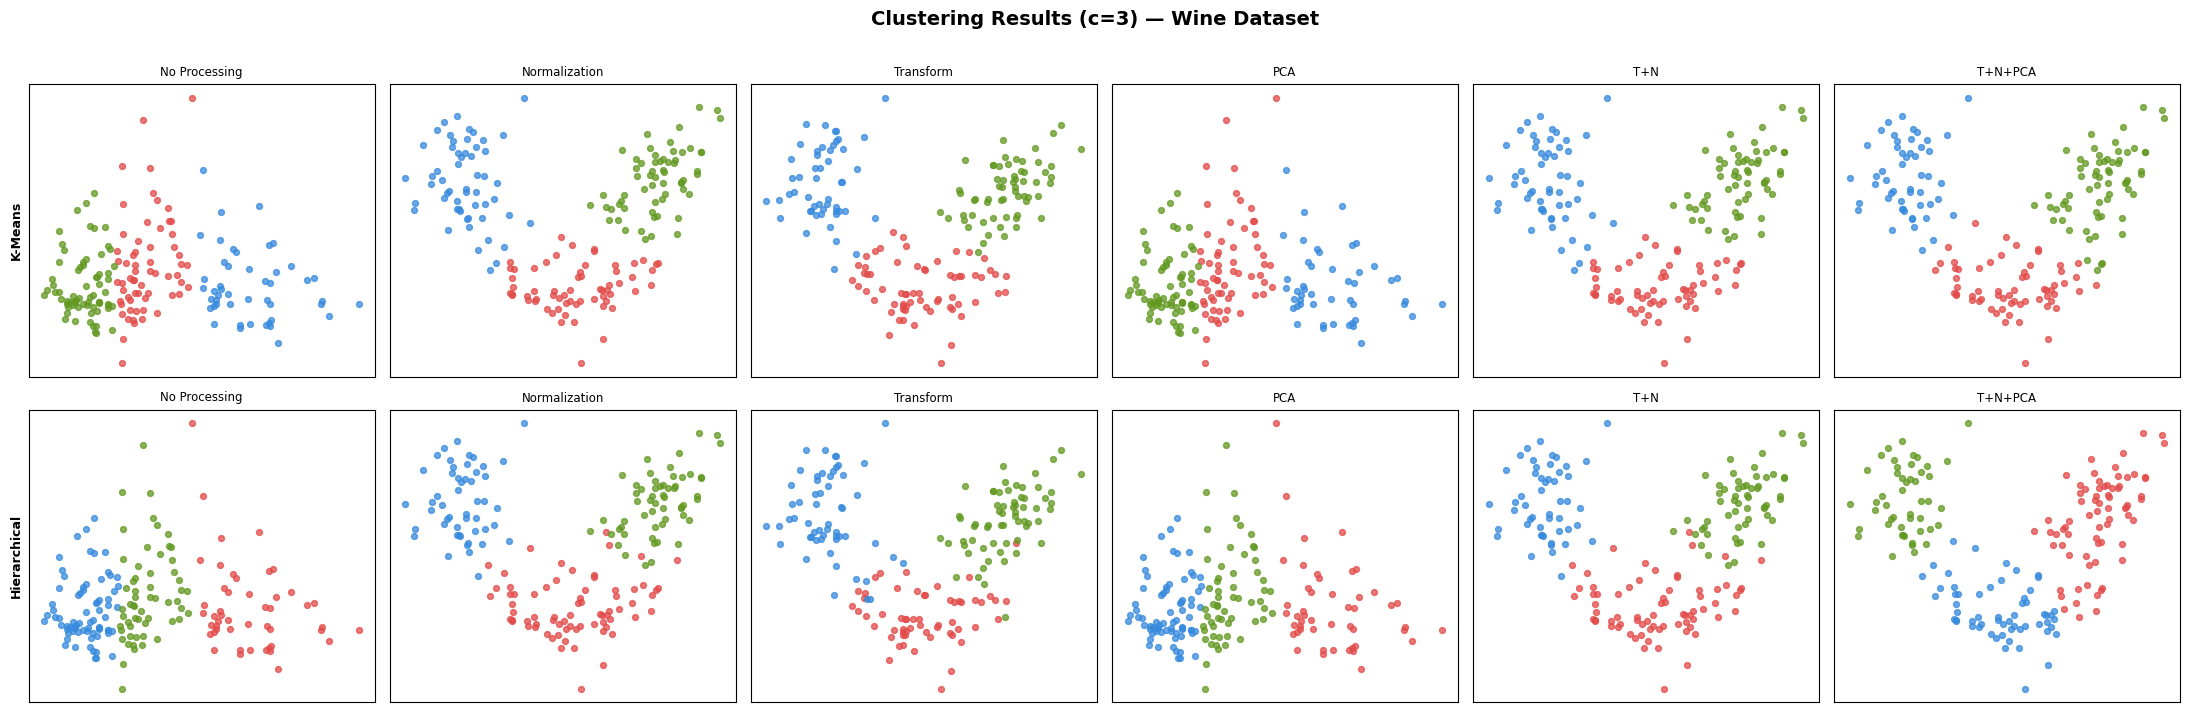

In [10]:
from sklearn.decomposition import PCA as PCA_viz

def get_2d(X):
    if X.shape[1] == 2:
        return X
    return PCA_viz(n_components=2, random_state=42).fit_transform(X)

prep_order = ['No Processing','Normalization','Transform','PCA','T+N','T+N+PCA']
COLORS = ['#E24B4A','#378ADD','#639922','#EF9F27','#9B59B6']

algos = {
    'K-Means':       lambda X,k: KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X),
    'Hierarchical':  lambda X,k: AgglomerativeClustering(n_clusters=k).fit_predict(X),
}

fig, axes = plt.subplots(2, 6, figsize=(22, 7))
fig.suptitle('Clustering Results (c=3) — Wine Dataset', fontsize=14, fontweight='bold', y=1.01)

for row_i, (algo_name, algo_fn) in enumerate(algos.items()):
    for col_i, prep in enumerate(prep_order):
        ax = axes[row_i][col_i]
        X  = preprocessings[prep]
        X2 = get_2d(X)
        labels = algo_fn(X, 3)
        for i in range(3):
            mask = labels == i
            ax.scatter(X2[mask,0], X2[mask,1], c=COLORS[i], s=18, alpha=0.75)
        ax.set_title(f'{prep}', fontsize=8.5)
        ax.set_xticks([]); ax.set_yticks([])
        if col_i == 0:
            ax.set_ylabel(algo_name, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('scatter_kmeans_hierarchical.png', dpi=150, bbox_inches='tight')
plt.show()


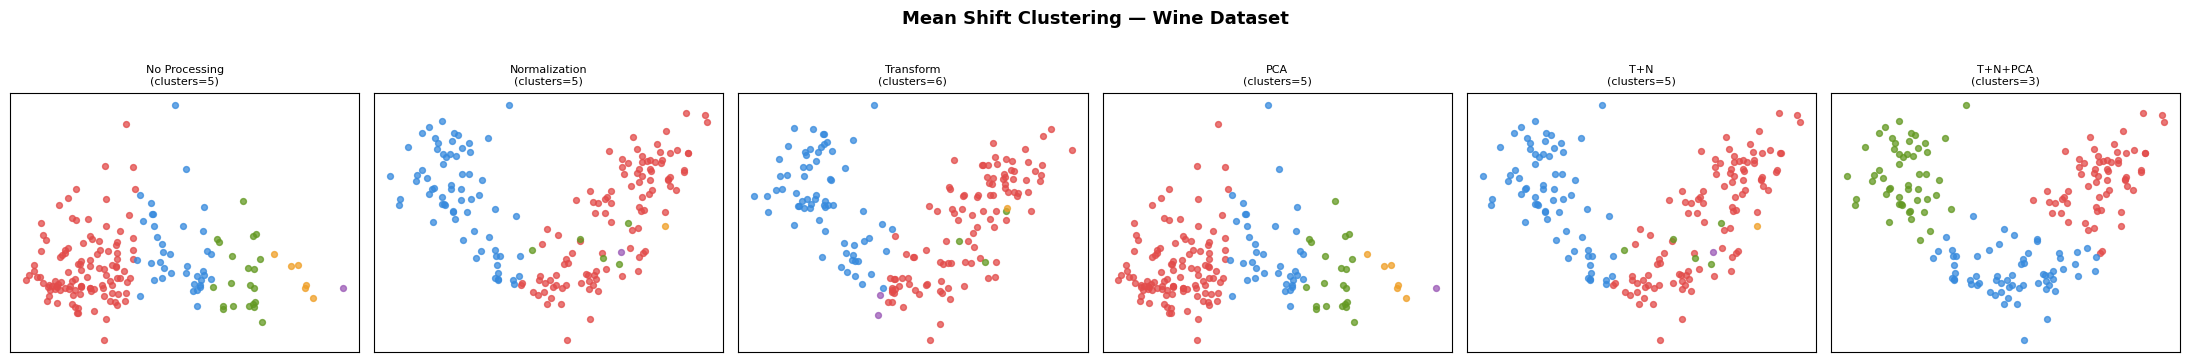

Saved: scatter_meanshift.png


In [11]:
fig, axes = plt.subplots(1, 6, figsize=(22, 3.5))
fig.suptitle('Mean Shift Clustering — Wine Dataset', fontsize=13, fontweight='bold', y=1.02)

for ax, prep in zip(axes, prep_order):
    X  = preprocessings[prep]
    X2 = get_2d(X)
    bw = estimate_bandwidth(X, quantile=0.2, random_state=42)
    if bw == 0: bw = 0.5
    labels  = MeanShift(bandwidth=bw).fit_predict(X)
    n_found = len(set(labels))
    for i in range(n_found):
        mask = labels == i
        ax.scatter(X2[mask,0], X2[mask,1], c=COLORS[i % len(COLORS)], s=18, alpha=0.75)
    ax.set_title(f'{prep}\n(clusters={n_found})', fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig('scatter_meanshift.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: scatter_meanshift.png")

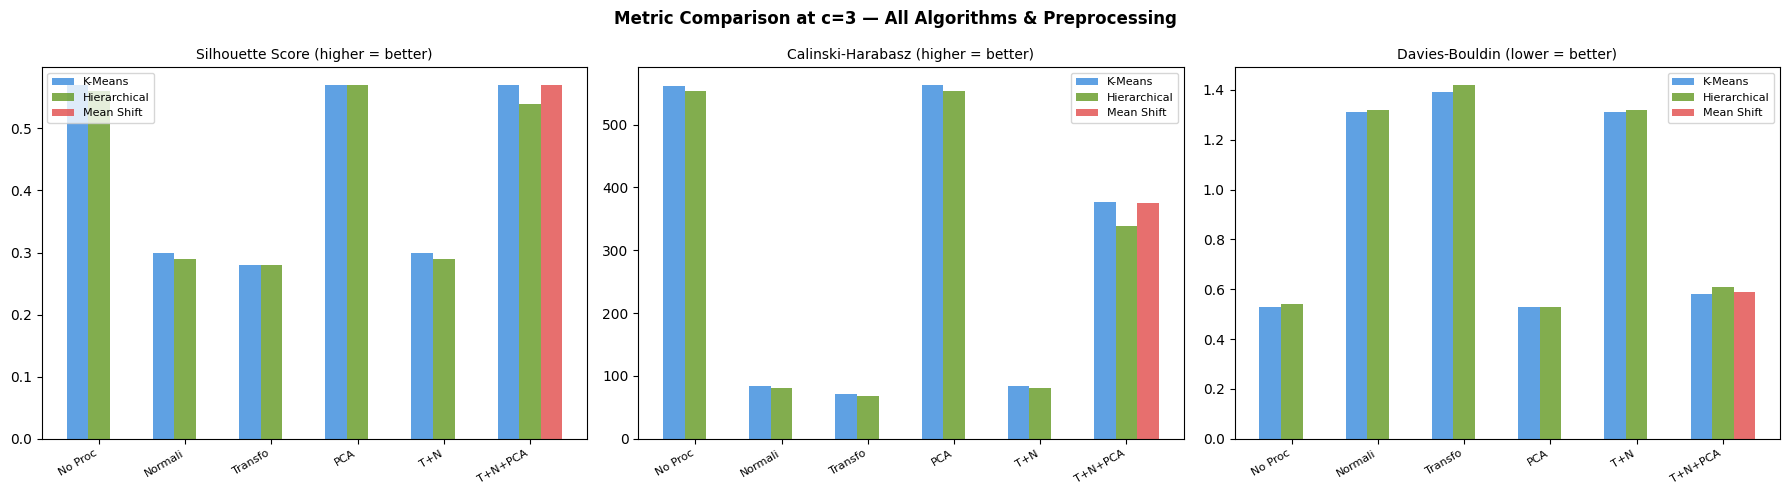

Saved: metric_comparison.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
algo_colors = {'K-Means':'#378ADD','Hierarchical':'#639922','Mean Shift':'#E24B4A'}
metrics_info = [
    ('Silhouette', 'Silhouette Score (higher = better)'),
    ('CH',         'Calinski-Harabasz (higher = better)'),
    ('DB',         'Davies-Bouldin (lower = better)'),
]
x = np.arange(len(prep_order))
width = 0.25

for ax, (metric, title) in zip(axes, metrics_info):
    for i, (algo, color) in enumerate(algo_colors.items()):
        vals = []
        for prep in prep_order:
            row = df_results[
                (df_results.Algorithm    == algo) &
                (df_results.Preprocessing == prep) &
                (df_results.k            == 3)
            ]
            v = row[metric].values[0] if len(row) > 0 else None
            try:    vals.append(float(v))
            except: vals.append(0)
        ax.bar(x + i*width, vals, width, label=algo, color=color, alpha=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_xticks(x + width)
    ax.set_xticklabels([p[:7] for p in prep_order], rotation=30, ha='right', fontsize=8)
    ax.legend(fontsize=8)

fig.suptitle('Metric Comparison at c=3 — All Algorithms & Preprocessing', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: metric_comparison.png")